<a href="https://colab.research.google.com/github/xyhosino/Machine_Learning/blob/main/%E6%9C%BA%E5%99%A8%E5%AD%A6%E4%B9%A0_%E7%AC%AC11%E8%AF%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import gymnasium as gym # gymnasium库
import numpy as np # Numpy库

状态数：  16
动作数：  4


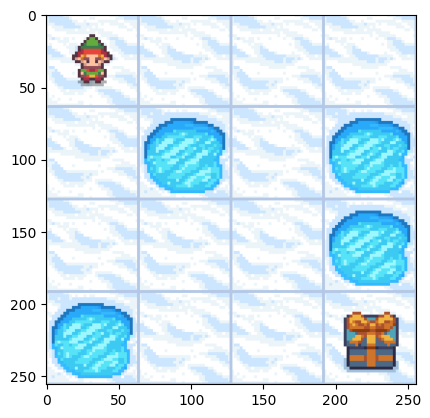

In [107]:
env = gym.make('FrozenLake-v1',is_slippery=True, render_mode='rgb_array') # 生成冰湖挑战环境
# env = gym.make('FrozenLake-v1',is_slippery=True) # 设定冰面会打滑（即智能体不会总是成功走到所希望移动的方向）
env.reset() # 初始化冰湖挑战环境
print("状态数： ", env.observation_space.n)
print("动作数： ", env.action_space.n)
plt.imshow(env.render())
plt.show()

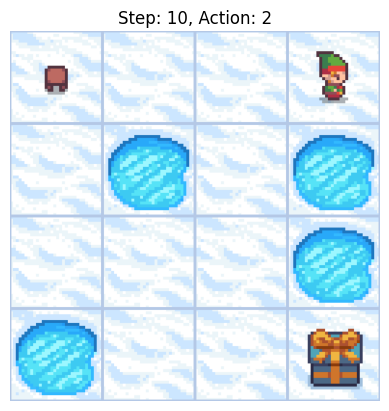

In [118]:
import random
import matplotlib.pyplot as plt
from IPython import display as ipythondisplay
import time

s, _ = env.reset()
for i in range(10):
    # 1. 随机选择动作
    action = random.randint(0, 3)

    # 2. 执行动作
    s, r, d, tr, _ = env.step(action)

    # 3. 绘图：必须放在循环内
    ipythondisplay.clear_output(wait=True) # 清除上一步的图
    plt.imshow(env.render())               # 拍下当前的照片
    plt.title(f"Step: {i+1}, Action: {action}")
    plt.axis('off')
    plt.show()                      # 显示照片

    # 4. 停顿：留出观察时间
    time.sleep(0.3)

    if d or tr: # 如果掉进洞里或到了终点，提前结束
        print("游戏结束！")
        break

In [104]:
# 初始化Q表
Q = np.zeros([env.observation_space.n,env.action_space.n])
print(Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


# **Q_Learning算法**

In [93]:
# 初始化参数
alpha = .6 # 学习速率
gamma = .75 # 奖励折扣
episodes = 500 # 游戏盘数
rList = [] # 记录每盘的总奖励
jList = [] # 记录每盘实际走了多少步

for i in range(episodes):
    s, _ = env.reset() # 重置环境
    rAll = 0
    done = False
    step_count = 0
    #Q-Learning算法实现
    while not done:
        step_count+=1
        # 通过Q-Table贪心的选择下一个动作，但是增加随机噪声，该噪声随着盘数的增加而减小
        a = np.argmax(Q[s,:] + np.random.randn(1,env.action_space.n)*(1./(i+1)))
        # 智能体执行动作，并从环境中得到新的状态和奖励
        s1, r, d, tr, _ = env.step(a)
        Q[s,a] = Q[s,a] + alpha*(r + gamma*np.max(Q[s1,:]) - Q[s,a])
        rAll += r
        s = s1
        done = d or tr
    rList.append(rAll)
    jList.append(step_count)
print(Q)
print("成功通关的盘数占比: " + str(sum(rList)/episodes))

[[0.00121306 0.00108424 0.00118742 0.00111063]
 [0.00143681 0.00045738 0.00056396 0.00108632]
 [0.00141033 0.00131139 0.00155252 0.00128519]
 [0.00056901 0.00134129 0.00092318 0.00144965]
 [0.00117973 0.00107376 0.00182753 0.00047604]
 [0.         0.         0.         0.        ]
 [0.00081969 0.00075447 0.0006961  0.00040515]
 [0.         0.         0.         0.        ]
 [0.00011659 0.00074663 0.00131012 0.01260249]
 [0.00356502 0.03664806 0.00418186 0.00251869]
 [0.00294517 0.01247753 0.00172377 0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.         0.03018675 0.         0.        ]
 [0.         0.         0.01996425 0.        ]
 [0.         0.         0.         0.        ]]
成功通关的盘数占比: 0.034


Score over time:0.034


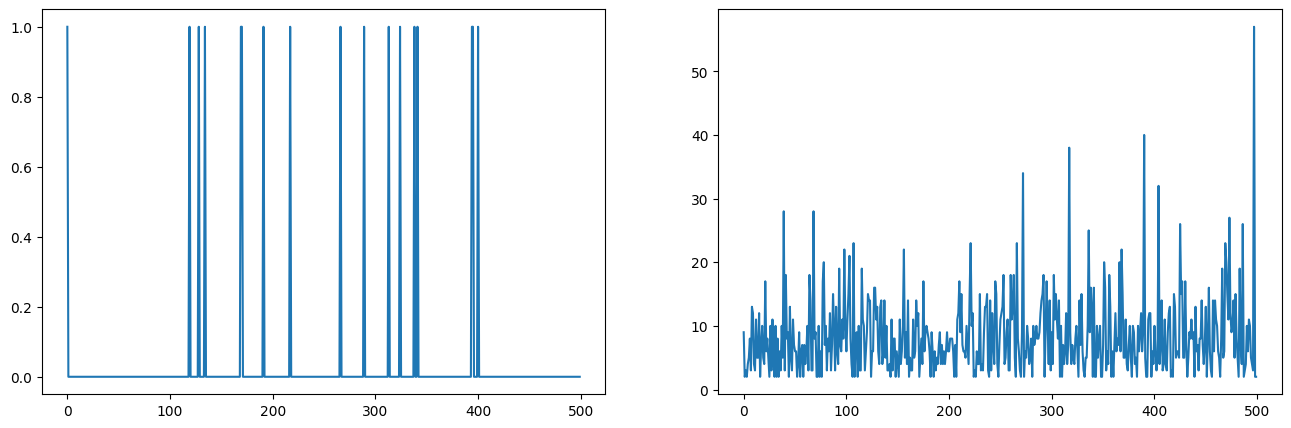

In [94]:
import matplotlib.pyplot as plt
print ("Score over time:"  +  str(sum(rList)/episodes))
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(rList)
plt.subplot(1,2,2)
plt.plot(jList)
plt.show()

# **SARSA算法**

In [95]:
Q = np.zeros([16,4])

In [96]:
# 初始化参数
alpha = .6 # 学习速率
gamma = .75 # 奖励折扣
episodes = 500 # 游戏盘数
rList = [] # 记录每盘的总奖励
jList = [] # 记录每盘实际走了多少步
for i in range(episodes):
    s,_ = env.reset() # 重置环境
    rAll = 0
    done = False
    step_count = 0
    # 这里使用简单的噪声法模拟 epsilon-greedy
    a = np.argmax(Q[s, :] + np.random.randn(1, env.action_space.n) * (1. / (i + 1)))
    #SARSA算法实现
    while not done:
        step_count+=1
        # 执行动作 a，得到新状态 s1
        s1, r, d, tr, _ = env.step(a)
        # 根据策略选出下一个动作 a1
        a1 = np.argmax(Q[s1, :] + np.random.randn(1, env.action_space.n) * (1. / (i + 1)))
        # 使用 SARSA 更新：利用“当前执行的动作a”和“下一时刻预定执行的动作a1”的Q值来更新
        Q[s,a] = Q[s,a] + alpha*(r + gamma*Q[s1,a1] - Q[s,a])
        rAll += r
        s = s1
        a = a1
        done = d or tr
    rList.append(rAll)
    jList.append(step_count)
print(Q)
print("成功通关的盘数占比: " + str(sum(rList)/episodes))

[[2.59235439e-03 1.79832404e-03 6.25006203e-03 4.74800981e-04]
 [1.65996104e-03 1.12705485e-04 3.56407962e-03 8.96959732e-04]
 [3.72019446e-03 1.57814288e-04 3.07957922e-04 2.15397667e-04]
 [1.61511756e-04 1.22095969e-03 1.47723844e-04 7.20002445e-04]
 [2.49730732e-03 6.60853331e-04 7.55965797e-04 2.81162719e-04]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.21395013e-03 1.41180027e-04 2.78955144e-04 5.92428318e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.01141085e-05 8.72491642e-04 1.17462382e-03 2.62425048e-02]
 [0.00000000e+00 7.91028577e-02 2.19067737e-03 0.00000000e+00]
 [0.00000000e+00 5.55765676e-02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 3.69765664e-02 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 3.11204714e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

Score over time:0.042


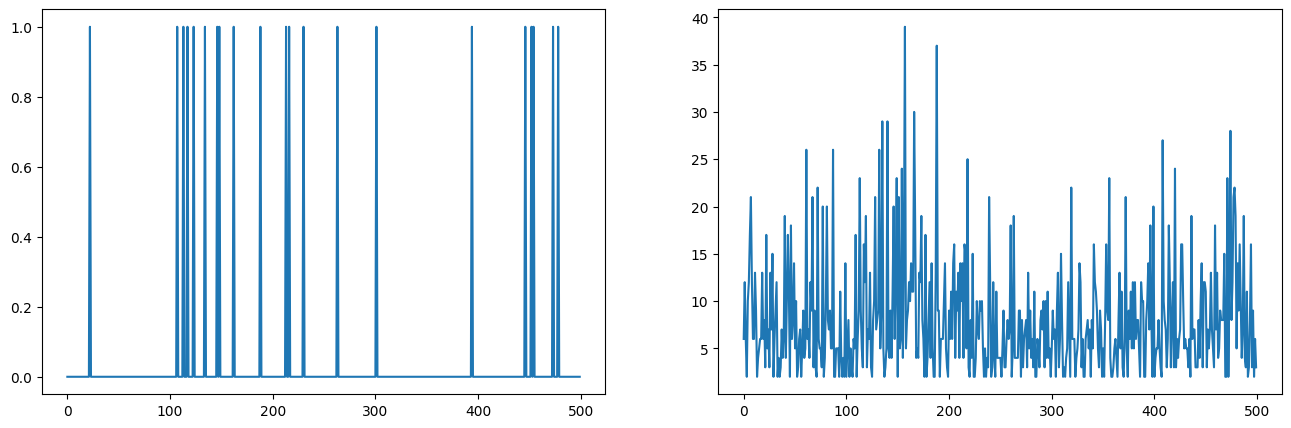

In [97]:
import matplotlib.pyplot as plt
print ("Score over time:"  +  str(sum(rList)/episodes))
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
plt.plot(rList)
plt.subplot(1,2,2)
plt.plot(jList)
plt.show()